# Quantitative Evaluation of Explainable Deep Reinforcement Learning (TD3) in Dairy Supply Chain Optimization


## Setup Device


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Ignore Warning


In [2]:
import warnings

warnings.filterwarnings("ignore")

## Creating Directory


In [3]:
from pathlib import Path

# Define your directory path
dir_path = Path("./plots")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

# Define your directory path
dir_path = Path("./results")

# Create directory safely
dir_path.mkdir(parents=True, exist_ok=True)

## Research-Grade Visualization


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 7),
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 2.0,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "axes.linewidth": 1.2,
    }
)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

## Load Data


In [5]:
import os
import kagglehub
import pandas as pd

print("Loading data...")
path = kagglehub.dataset_download("debarghamitraroy/dairy-production-dataset")
data_path = os.path.join(path, "train.csv")
df = pd.read_csv(data_path)
print("Data loading was successful...")

Loading data...
Data loading was successful...


In [6]:
num_rows, num_cols = df.shape
print(f"Rows: {num_rows}")
print(f"Columns: {num_cols}")

Rows: 122983
Columns: 24


## Environment Formulation & Offline Data Engineering


### Temporal Feature Engineering


In [7]:
print("Processing temporal features...")

# Convert date columns to datetime objects dates are in DD-MM-YYYY format
date_cols = ["Date", "Production Date", "Expiration Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d-%m-%Y", errors="coerce")

# Calculate 'Days to Expiration'
df["Days_to_Expiration"] = (df["Expiration Date"] - df["Date"]).dt.days

# Drop rows where expiration is negative
df = df[df["Days_to_Expiration"] >= 0].copy()

# Calculate Age of product since production
df["Product_Age_Days"] = (df["Date"] - df["Production Date"]).dt.days

print("Processing temporal features was successful...")

Processing temporal features...
Processing temporal features was successful...


### Age-Structured Inventory Matrix (FIFO)


In [8]:
print("Building FIFO age-structured matrices...")
MAX_SHELF_LIFE = 30

fifo_matrix = df.pivot_table(
    index=["Date", "Product ID"],
    columns="Days_to_Expiration",
    values="Quantity in Stock (liters/kg)",
    aggfunc="sum",
    fill_value=0,
)

cols_to_keep = [col for col in fifo_matrix.columns if col <= MAX_SHELF_LIFE]
cols_to_group = [col for col in fifo_matrix.columns if col > MAX_SHELF_LIFE]

if cols_to_group:
    fifo_matrix[f">{MAX_SHELF_LIFE}_Days"] = fifo_matrix[cols_to_group].sum(axis=1)
    fifo_matrix = fifo_matrix.drop(columns=cols_to_group)

fifo_matrix.columns = [
    f"Stock_Expiring_in_{int(col)}_Days" if isinstance(col, (int, float)) else col
    for col in fifo_matrix.columns
]

print(f"Created FIFO matrix with shape: {fifo_matrix.shape}")

Building FIFO age-structured matrices...
Created FIFO matrix with shape: (56546, 32)


### Multicollinearity Detection


In [9]:
import numpy as np

print("Analyzing Multicollinearity for XAI ROAR/PI evaluation...")

numerical_df = df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

COLLINEAR_THRESHOLD = 0.85

collinear_pairs = [
    (upper_tri.columns[i], upper_tri.columns[j], upper_tri.iloc[i, j])
    for i in range(len(upper_tri.columns))
    for j in range(i + 1, len(upper_tri.columns))
    if upper_tri.iloc[i, j] > COLLINEAR_THRESHOLD
]

print(f"\nHighly Collinear Feature Pairs (Threshold > {COLLINEAR_THRESHOLD}):")
for feat1, feat2, corr_val in collinear_pairs:
    print(f"[{corr_val:.3f}] {feat1} <--> {feat2}")

Analyzing Multicollinearity for XAI ROAR/PI evaluation...

Highly Collinear Feature Pairs (Threshold > 0.85):
[0.988] Price per Unit <--> Price per Unit (sold)


## State & Action Formulation


### Create the RL Environment DataFrame


In [10]:
rl_df = df.merge(fifo_matrix, on=["Date", "Product ID"], how="left")
rl_df.fillna(0, inplace=True)
print("Shape:", rl_df.shape)

Shape: (60035, 58)


### Encode Categorical Variables


In [11]:
import joblib
from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Encoding categorical variables...")
categorical_cols = [
    "Location",
    "Farm Size",
    "Product Name",
    "Brand",
    "Storage Condition",
    "Sales Channel",
]
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    rl_df[col] = le.fit_transform(rl_df[col].astype(str))
    encoders[col] = le

Encoding categorical variables...


### Define State (S) Features


In [12]:
state_cols = [
    "Location",
    "Total Land Area (acres)",
    "Number of Cows",
    "Farm Size",
    "Product ID",
    "Product Name",
    "Brand",
    "Shelf Life (days)",
    "Storage Condition",
    "Quantity in Stock (liters/kg)",
    "Minimum Stock Threshold (liters/kg)",
    "Price per Unit",
    "Days_to_Expiration",
    "Product_Age_Days",
] + list(fifo_matrix.columns)

print(f"State vector comprises {len(state_cols)} dimensions.")

State vector comprises 46 dimensions.


### Define Action (A) Features


In [13]:
action_cols = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]
print(f"Action vector comprises {len(action_cols)} dimensions.")

Action vector comprises 2 dimensions.


### Extract and Scale the Matrices


In [14]:
print("\nScaling State and Action matrices...")
scaler_S = StandardScaler()
scaler_A = StandardScaler()

S_raw = rl_df[state_cols].values
A_raw = rl_df[action_cols].values

S_matrix = scaler_S.fit_transform(S_raw)
A_matrix = scaler_A.fit_transform(A_raw)

print(f"-> State Space (S) shape: {S_matrix.shape}")
print(f"-> Action Space (A) shape: {A_matrix.shape}")

rl_df_final = rl_df.copy()
print("\nState and Action formulation completed successfully...")


Scaling State and Action matrices...
-> State Space (S) shape: (60035, 46)
-> Action Space (A) shape: (60035, 2)

State and Action formulation completed successfully...


## Reward Engineering & Shaping


### Base Financial Sub-Rewards (Multi-Objective Decomposition)


In [15]:
df_reward = rl_df_final.copy()
print("Calculating financial sub-rewards...")

# A. Gross Profit
rl_df_final["Gross_Profit"] = rl_df_final["Approx. Total Revenue(INR)"] - (
    rl_df_final["Quantity Sold (liters/kg)"] * rl_df_final["Price per Unit"]
)

# B. Waste Penalty
waste_col = (
    "Stock_Expiring_in_0_Days"
    if "Stock_Expiring_in_0_Days" in rl_df_final.columns
    else "Stock_Expiring_in_1_Days"
)
rl_df_final["Waste_Penalty"] = (
    rl_df_final[waste_col] * rl_df_final["Price per Unit"] * 1.5
)

# C. Holding Cost
rl_df_final["Holding_Cost"] = (
    rl_df_final["Quantity in Stock (liters/kg)"] * rl_df_final["Price per Unit"] * 0.05
)

# D. Stockout Penalty
rl_df_final["Stockout_Penalty"] = np.where(
    rl_df_final["Quantity in Stock (liters/kg)"]
    < rl_df_final["Minimum Stock Threshold (liters/kg)"],
    (
        rl_df_final["Minimum Stock Threshold (liters/kg)"]
        - rl_df_final["Quantity in Stock (liters/kg)"]
    )
    * rl_df_final["Price per Unit"]
    * 2.0,
    0,
)

Calculating financial sub-rewards...


### Aggregating the Raw Reward


In [16]:
print("Aggregating Raw Reward...")
rl_df_final["Raw_Reward"] = (
    rl_df_final["Gross_Profit"]
    - rl_df_final["Waste_Penalty"]
    - rl_df_final["Holding_Cost"]
    - rl_df_final["Stockout_Penalty"]
)
print("Aggregating Raw Reward successfully...")

Aggregating Raw Reward...
Aggregating Raw Reward successfully...


### Preference As Reward (PAR) Bounding


In [17]:
print("Applying Preference As Reward (PAR) bounding...")
r_median = rl_df_final["Raw_Reward"].median()
r_std = rl_df_final["Raw_Reward"].std()


def par_transform(r, ref, std, k=2.0):
    return 2 / (1 + np.exp(-k * (r - ref) / std)) - 1


rl_df_final["Bounded_Reward_PAR"] = par_transform(
    rl_df_final["Raw_Reward"], r_median, r_std
)

print("Applying Preference As Reward (PAR) bounding successfully...")

Applying Preference As Reward (PAR) bounding...
Applying Preference As Reward (PAR) bounding successfully...


### Extract Final MDP Arrays for Training


In [18]:
# The Reward array (R)
R_matrix = rl_df_final["Bounded_Reward_PAR"].values

print("\nReward Summary Statistics:")
print(rl_df_final[["Raw_Reward", "Bounded_Reward_PAR"]].describe())

print(f"\n-> Reward Space (R) shape: {R_matrix.shape}")


Reward Summary Statistics:
          Raw_Reward  Bounded_Reward_PAR
count   60035.000000        60035.000000
mean    -2024.795992           -0.048919
std      7576.005953            0.492767
min   -149276.123916           -1.000000
25%     -4334.923495           -0.390078
50%     -1214.426635            0.000000
75%       716.080589            0.249443
max     60077.369805            1.000000

-> Reward Space (R) shape: (60035,)


## Deep RL Surrogate Training (Offline TD3)


### Replay Buffer Initialization & Transition Engineering


#### Temporal Transition Engineering (S, A, R, S')


In [19]:
print("Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...")

rl_df_final = rl_df_final.sort_values(
    by=["Location", "Product ID", "Date"]
).reset_index(drop=True)

S_raw = rl_df_final[state_cols].values
A_matrix = scaler_A.transform(rl_df_final[action_cols].values)
R_matrix = rl_df_final["Bounded_Reward_PAR"].values
S_matrix = scaler_S.transform(S_raw)

S_next_matrix = np.roll(S_matrix, shift=-1, axis=0)

is_terminal = (
    (rl_df_final["Product ID"] != rl_df_final["Product ID"].shift(-1))
    | (rl_df_final["Location"] != rl_df_final["Location"].shift(-1))
).values.copy()

is_terminal[-1] = True

print(f"Extracted {len(S_matrix)} total transitions.")
print(f"Identified {is_terminal.sum()} terminal states (Episode boundaries).")

Extracting MDP Transitions (S_t, A_t, R_t, S_t+1)...
Extracted 60035 total transitions.
Identified 54196 terminal states (Episode boundaries).


### Offline TD3 Rollout Buffer Preparation (GAE Support)


In [20]:
import torch

print(
    "Initializing Offline Rollout Buffer for Generalized Advantage Estimation (GAE)..."
)


class OfflineRolloutBuffer:
    def __init__(self, states, actions, rewards, next_states, dones):
        self.states = torch.tensor(states.copy(), dtype=torch.float32)
        self.actions = torch.tensor(actions.copy(), dtype=torch.float32)
        self.rewards = torch.tensor(rewards.copy(), dtype=torch.float32).unsqueeze(1)
        self.next_states = torch.tensor(next_states.copy(), dtype=torch.float32)
        self.dones = torch.tensor(dones.copy(), dtype=torch.float32).unsqueeze(1)
        self.size = len(states)

    def compute_gae(self, model, device, gamma=0.99, lam=0.95):
        """
        Computes GAE (Generalized Advantage Estimation) across the offline dataset
        using the network's current value function. Preserves episode boundaries via `dones`.
        """
        states_d = self.states.to(device)
        next_states_d = self.next_states.to(device)
        rewards_d = self.rewards.to(device)
        dones_d = self.dones.to(device)

        with torch.no_grad():
            _, values, _ = model(states_d)
            _, next_values, _ = model(next_states_d)

        # Move to CPU for efficient sequential processing
        values_np = values.cpu().numpy()
        next_values_np = next_values.cpu().numpy()
        rewards_np = rewards_d.cpu().numpy()
        dones_np = dones_d.cpu().numpy()

        advantages_np = np.zeros_like(rewards_np)
        gae = 0
        for t in reversed(range(self.size)):
            delta = (
                rewards_np[t]
                + gamma * next_values_np[t] * (1 - dones_np[t])
                - values_np[t]
            )
            gae = delta + gamma * lam * (1 - dones_np[t]) * gae
            advantages_np[t] = gae

        returns_np = advantages_np + values_np

        self.advantages = torch.tensor(advantages_np, dtype=torch.float32)
        self.returns = torch.tensor(returns_np, dtype=torch.float32)

        # Advantage Normalization
        adv_mean = self.advantages.mean()
        adv_std = self.advantages.std()
        self.advantages = (self.advantages - adv_mean) / (adv_std + 1e-8)

    def get_batches(self, batch_size, old_log_probs):
        """
        Yields randomized mini-batches for the clipped surrogate objective updates.
        """
        indices = np.random.permutation(self.size)
        for start in range(0, self.size, batch_size):
            end = start + batch_size
            idx = indices[start:end]
            yield (
                self.states[idx],
                self.actions[idx],
                self.advantages[idx],
                self.returns[idx],
                old_log_probs[idx],
            )


offline_buffer = OfflineRolloutBuffer(
    states=S_matrix,
    actions=A_matrix,
    rewards=R_matrix,
    next_states=S_next_matrix,
    dones=is_terminal,
)

print(f"Rollout Buffer populated with {offline_buffer.size} static transitions.")

Initializing Offline Rollout Buffer for Generalized Advantage Estimation (GAE)...
Rollout Buffer populated with 60035 static transitions.


### TD3 Actor-Critic Network Architecture


#### Gaussian Actor-Critic Network


In [21]:
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal


class TD3PPOModel(nn.Module):
    """
    Implements a Gaussian Policy network compatible with clipped TD3 objectives.
    Contains a shared feature encoder, a continuous Action mean branch, and a Value branch.
    """

    def __init__(self, state_dim, action_dim):
        super(TD3PPOModel, self).__init__()

        # Shared Feature Extractor (Encoder)
        self.shared_layers = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
        )

        # Value Function (Critic Network)
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

        # Policy Mean Output (Actor Network)
        self.action_mean = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
        )

        # Learnable action standard deviation for exploration & entropy calculations
        self.action_log_std = nn.Parameter(torch.zeros(1, action_dim))

    def forward(self, state):
        shared_features = self.shared_layers(state)
        V = self.value_stream(shared_features)
        A_mean = self.action_mean(shared_features)

        # Returned format `None, V, A_mean` elegantly interfaces with
        # the exact evaluation & XAI pipeline wrappers mapped from previous architectures.
        return None, V, A_mean

    def evaluate_actions(self, state, action):
        """
        Computes the log probabilities and entropy of offline actions under the current Gaussian policy.
        """
        shared_features = self.shared_layers(state)
        A_mean = self.action_mean(shared_features)
        action_std = self.action_log_std.exp().expand_as(A_mean)

        dist = Normal(A_mean, action_std)
        log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
        entropy = dist.entropy().sum(dim=-1, keepdim=True)

        return log_prob, entropy

### Initialization & Architecture Validation


In [22]:
print("Instantiating TD3 Architecture...")

STATE_DIM = 46
ACTION_DIM = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model
# We assign the model to 'dueling_model' so it serves as a seamless drop-in
# replacement for the un-modified evaluation and XAI cells.
dueling_model = TD3PPOModel(state_dim=STATE_DIM, action_dim=ACTION_DIM).to(device)

print(f"Model successfully mapped to device: {device}")

# Sanity Check Forward Pass
print("\nTesting Forward Pass & Gradient Flow...")
dummy_states = torch.randn(64, STATE_DIM).to(device)
dummy_actions = torch.randn(64, ACTION_DIM).to(device)

_, State_Values, A_Mean = dueling_model(dummy_states)
log_probs, entropy = dueling_model.evaluate_actions(dummy_states, dummy_actions)

print(f"-> Input State Shape: {dummy_states.shape}")
print(f"-> Output V(s) Shape: {State_Values.shape} (Scalar Value Loss)")
print(f"-> Output A_Mean Shape: {A_Mean.shape} (Policy Mean Output)")
print(f"-> Output Log Probabilities Shape: {log_probs.shape} (Policy Ratio)")
print("Testing Forward Pass & Gradient Flow successfully...")

Instantiating TD3 Architecture...
Model successfully mapped to device: cuda

Testing Forward Pass & Gradient Flow...
-> Input State Shape: torch.Size([64, 46])
-> Output V(s) Shape: torch.Size([64, 1]) (Scalar Value Loss)
-> Output A_Mean Shape: torch.Size([64, 2]) (Policy Mean Output)
-> Output Log Probabilities Shape: torch.Size([64, 1]) (Policy Ratio)
Testing Forward Pass & Gradient Flow successfully...


### Offline TD3 Optimization


#### Training Hyperparameters


In [23]:
EPOCHS = 15
BATCH_SIZE = 2048  # Mini-batch optimization
GAMMA = 0.99  # Discount factor for future rewards
GAE_LAMBDA = 0.95  # Lambda parameter for GAE
CLIP_EPS = 0.2  # TD3 Surrogate Clipping Threshold
ENTROPY_COEF = 0.01  # Entropy bonus regularization
LR = 3e-4

optimizer = optim.Adam(dueling_model.parameters(), lr=LR)

steps_per_epoch = offline_buffer.size // BATCH_SIZE
print(f"Starting Training: {EPOCHS} Epochs, {steps_per_epoch} Steps per Epoch")

# Metrics tracking for future XAI comparison
training_history = {"critic_loss": [], "actor_loss": [], "entropy_loss": []}

Starting Training: 15 Epochs, 29 Steps per Epoch


### Main Offline TD3 Training Loop


In [24]:
import time

start_time = time.time()
dueling_model.train()

for epoch in range(EPOCHS):
    # 1. GAE Computation:
    # Evaluate advantage of recorded historical actions against current value baseline
    offline_buffer.compute_gae(dueling_model, device, gamma=GAMMA, lam=GAE_LAMBDA)

    # 2. Extract baseline Action Log-Probabilities (`pi_old`) prior to update steps
    with torch.no_grad():
        old_log_probs, _ = dueling_model.evaluate_actions(
            offline_buffer.states.to(device), offline_buffer.actions.to(device)
        )
        old_log_probs = old_log_probs.cpu()

    epoch_c_loss = 0.0
    epoch_a_loss = 0.0
    epoch_entropy = 0.0
    steps = 0

    # 3. Mini-batch Optimization (Multiple Epoch Updates)
    for (
        states_b,
        actions_b,
        adv_b,
        ret_b,
        old_log_probs_b,
    ) in offline_buffer.get_batches(BATCH_SIZE, old_log_probs):
        states_b = states_b.to(device)
        actions_b = actions_b.to(device)
        adv_b = adv_b.to(device).unsqueeze(1)
        ret_b = ret_b.to(device).unsqueeze(1)
        old_log_probs_b = old_log_probs_b.to(device)

        optimizer.zero_grad()

        # Evaluate mini-batch with current network weights
        new_log_probs, entropy = dueling_model.evaluate_actions(states_b, actions_b)
        _, v_pred, _ = dueling_model(states_b)

        # Policy Ratio
        ratio = torch.exp(new_log_probs - old_log_probs_b)

        # Clipped TD3 Surrogate Loss
        surr1 = ratio * adv_b
        surr2 = torch.clamp(ratio, 1.0 - CLIP_EPS, 1.0 + CLIP_EPS) * adv_b
        actor_loss = -torch.min(surr1, surr2).mean()

        # Value Loss (MSE)
        value_loss = nn.MSELoss()(v_pred, ret_b)

        # Entropy Regularization (Exploration Bonus)
        entropy_loss = entropy.mean()

        # Combined Network Loss
        total_loss = actor_loss + 0.5 * value_loss - ENTROPY_COEF * entropy_loss
        total_loss.backward()

        # Optimize step
        optimizer.step()

        epoch_c_loss += value_loss.item()
        epoch_a_loss += actor_loss.item()
        epoch_entropy += entropy_loss.item()
        steps += 1

    # Epoch Logging
    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Value Loss: {epoch_c_loss / steps:.4f} | "
        f"Policy Loss: {epoch_a_loss / steps:.4f} | "
        f"Entropy: {epoch_entropy / steps:.4f}"
    )

    training_history["critic_loss"].append(epoch_c_loss / steps)
    training_history["actor_loss"].append(epoch_a_loss / steps)
    training_history["entropy_loss"].append(epoch_entropy / steps)

Epoch 01/15 | Value Loss: 0.5197 | Policy Loss: -0.0004 | Entropy: 2.8466
Epoch 02/15 | Value Loss: 0.5348 | Policy Loss: 0.0013 | Entropy: 2.8641
Epoch 03/15 | Value Loss: 0.5344 | Policy Loss: -0.0001 | Entropy: 2.8813
Epoch 04/15 | Value Loss: 0.5339 | Policy Loss: -0.0003 | Entropy: 2.8990
Epoch 05/15 | Value Loss: 0.5325 | Policy Loss: -0.0007 | Entropy: 2.9162
Epoch 06/15 | Value Loss: 0.5334 | Policy Loss: -0.0004 | Entropy: 2.9340
Epoch 07/15 | Value Loss: 0.5331 | Policy Loss: 0.0001 | Entropy: 2.9515
Epoch 08/15 | Value Loss: 0.5333 | Policy Loss: -0.0006 | Entropy: 2.9688
Epoch 09/15 | Value Loss: 0.5315 | Policy Loss: 0.0004 | Entropy: 2.9865
Epoch 10/15 | Value Loss: 0.5303 | Policy Loss: 0.0004 | Entropy: 3.0038
Epoch 11/15 | Value Loss: 0.5326 | Policy Loss: 0.0001 | Entropy: 3.0218
Epoch 12/15 | Value Loss: 0.5363 | Policy Loss: 0.0012 | Entropy: 3.0397
Epoch 13/15 | Value Loss: 0.5326 | Policy Loss: -0.0002 | Entropy: 3.0577
Epoch 14/15 | Value Loss: 0.5283 | Policy Lo

### TD3 Evaluation & Regression Metrics


In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score,
)

print("\nExecuting Comprehensive Prediction Profiling...")

# Convert S_matrix to tensor
S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)

dueling_model.eval()
with torch.no_grad():
    _, V_pred, A_pred_tensor = dueling_model(S_tensor)
    A_pred_scaled = A_pred_tensor.cpu().numpy()

# Inverse transform for true real-world scaling
A_true_real = scaler_A.inverse_transform(A_matrix)
A_pred_real = scaler_A.inverse_transform(A_pred_scaled)


def calculate_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    # NRMSE Accuracy: Accuracy (%) = (1 - NRMSE) * 100
    nrmse = rmse / (y_true.max() - y_true.min())
    acc = max(0, (1 - nrmse) * 100)

    print(f"{name} Predictions:")
    print(
        f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | EV Score: {evs:.4f} | Accuracy: {acc:.2f}%"
    )
    return mae, rmse, r2, acc


p_mae, p_rmse, p_r2, p_acc = calculate_metrics(
    A_true_real[:, 0], A_pred_real[:, 0], "Pricing Strategy"
)
r_mae, r_rmse, r_r2, r_acc = calculate_metrics(
    A_true_real[:, 1], A_pred_real[:, 1], "Reordering Strategy"
)
overall_drl_acc = (p_acc + r_acc) / 2
print(f"Overall Target Policy Accuracy: {overall_drl_acc:.2f}%")


Executing Comprehensive Prediction Profiling...
Pricing Strategy Predictions:
MAE: 23.0733 | RMSE: 26.9388 | R²: -0.0300 | EV Score: -0.0222 | Accuracy: 72.87%
Reordering Strategy Predictions:
MAE: 44.7835 | RMSE: 52.3331 | R²: -0.0199 | EV Score: -0.0027 | Accuracy: 70.91%
Overall Target Policy Accuracy: 71.89%


#### Generate Publication-Quality Evaluation Visualizations


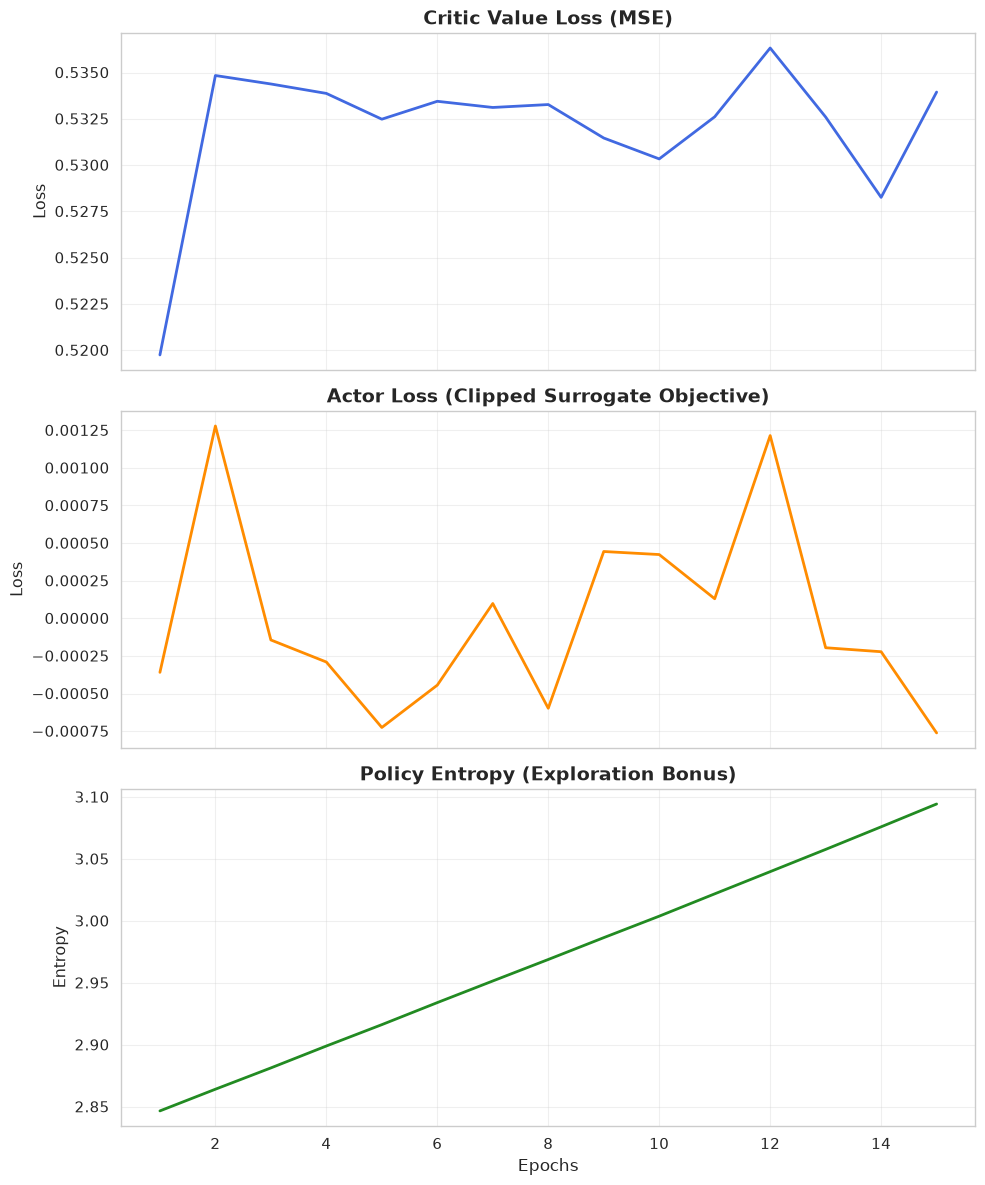

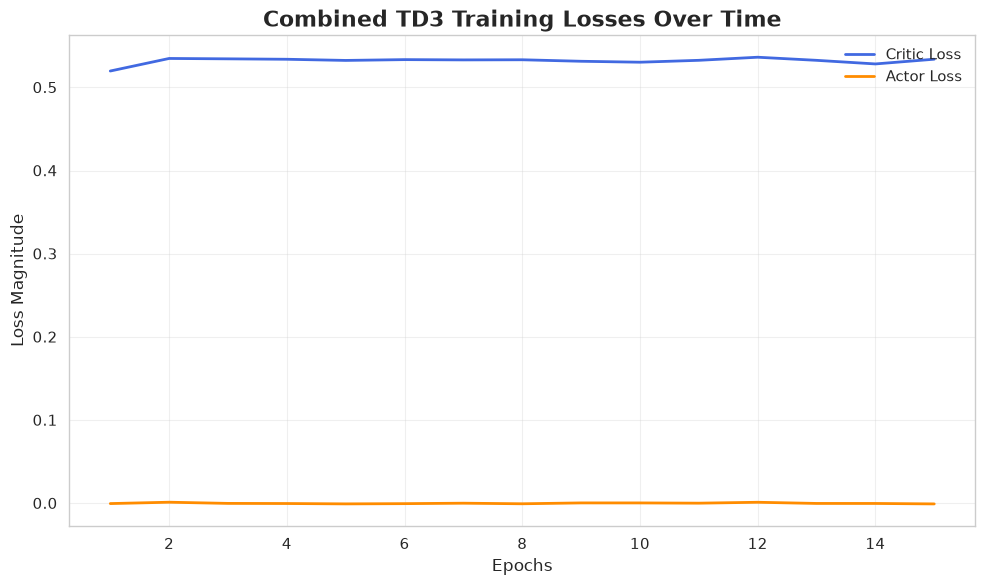

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_training_metrics(training_history):
    """
    Plots the training history using Matplotlib and Seaborn.
    Expects a dictionary with keys: 'critic_loss', 'actor_loss', 'entropy_loss'
    """
    epochs = range(1, len(training_history["critic_loss"]) + 1)
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=True)

    # 1. Value Loss Plot
    sns.lineplot(
        x=epochs,
        y=training_history["critic_loss"],
        ax=axes[0],
        color="royalblue",
        linewidth=2,
    )
    axes[0].set_title("Critic Value Loss (MSE)", fontsize=14, fontweight="bold")
    axes[0].set_ylabel("Loss")

    # 2. Policy Loss Plot
    sns.lineplot(
        x=epochs,
        y=training_history["actor_loss"],
        ax=axes[1],
        color="darkorange",
        linewidth=2,
    )
    axes[1].set_title(
        "Actor Loss (Clipped Surrogate Objective)", fontsize=14, fontweight="bold"
    )
    axes[1].set_ylabel("Loss")

    # 3. Entropy Loss Plot
    sns.lineplot(
        x=epochs,
        y=training_history["entropy_loss"],
        ax=axes[2],
        color="forestgreen",
        linewidth=2,
    )
    axes[2].set_title(
        "Policy Entropy (Exploration Bonus)", fontsize=14, fontweight="bold"
    )
    axes[2].set_ylabel("Entropy")
    axes[2].set_xlabel("Epochs", fontsize=12)

    plt.tight_layout()
    plt.show()

    # Combined Overlay Plot
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        x=epochs,
        y=training_history["critic_loss"],
        label="Critic Loss",
        color="royalblue",
        linewidth=2,
    )
    sns.lineplot(
        x=epochs,
        y=training_history["actor_loss"],
        label="Actor Loss",
        color="darkorange",
        linewidth=2,
    )

    plt.title("Combined TD3 Training Losses Over Time", fontsize=16, fontweight="bold")
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("Loss Magnitude", fontsize=12)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig("./plots/TD3_Training_Losses.pdf", format="pdf", dpi=1200)
    plt.show()


plot_training_metrics(training_history)

#### Save the Final Surrogate Model


In [27]:
# torch.save(dueling_model.state_dict(), "./model/TD3_dueling_model.pth")
elapsed_time = time.time() - start_time
print(f"\nOffline Deep RL Training Completed in {elapsed_time / 60:.2f} minutes.")
# print("Models saved to './model/' directory.")


Offline Deep RL Training Completed in 0.22 minutes.


## Explainable AI (XRL) Generation


### Local Explanations via SHAP (Step-by-Step Inference)


#### PyTorch Model Wrapper for SHAP


In [28]:
# SHAP requires a model that takes an input tensor and returns a single output tensor.
class ActionStreamWrapper(nn.Module):
    def __init__(self, dueling_model):
        super(ActionStreamWrapper, self).__init__()
        self.model = dueling_model

    def forward(self, x):
        _, _, A = self.model(x)
        return A


action_model = ActionStreamWrapper(dueling_model).to(device)
action_model.eval()

ActionStreamWrapper(
  (model): TD3PPOModel(
    (shared_layers): Sequential(
      (0): Linear(in_features=46, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
      (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
      (5): ReLU()
    )
    (value_stream): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=1, bias=True)
    )
    (action_mean): Sequential(
      (0): Linear(in_features=128, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=2, bias=True)
    )
  )
)

#### Prepare Background and Test Data


In [29]:
print("Preparing background distributions for SHAP...")
rng = np.random.default_rng(42)
background_indices = rng.choice(S_matrix.shape[0], size=200, replace=False)
background_tensor = torch.tensor(S_matrix[background_indices], dtype=torch.float32).to(
    device
)

test_indices = np.arange(5)
test_tensor = torch.tensor(S_matrix[test_indices], dtype=torch.float32).to(device)

print("Preparing background distributions for SHAP completed successfully...")

Preparing background distributions for SHAP...
Preparing background distributions for SHAP completed successfully...


#### Initialize GradientExplainer & Compute SHAP


In [30]:
import shap

print("Initializing SHAP GradientExplainer...")
explainer = shap.GradientExplainer(action_model, background_tensor)

print("Calculating SHAP values for test instances...")
shap_values = explainer.shap_values(test_tensor)

if not isinstance(shap_values, list):
    shap_values = [shap_values[:, :, 0], shap_values[:, :, 1]]

print("\nSHAP values successfully computed.")

Initializing SHAP GradientExplainer...
Calculating SHAP values for test instances...

SHAP values successfully computed.


#### Visualizing Local Explanations



Generating Local Explanation for Action: Price per Unit (sold) (Transaction #0)


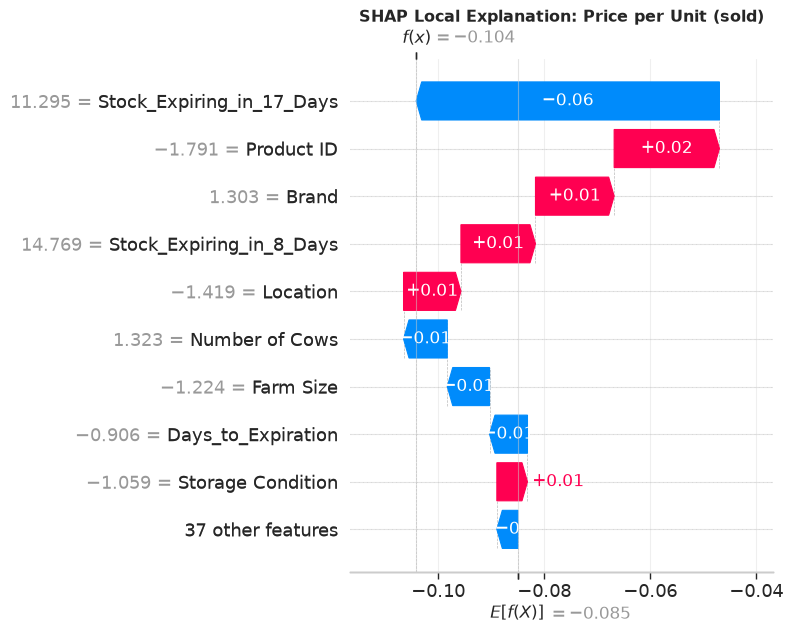


Generating Local Explanation for Action: Reorder Quantity (liters/kg) (Transaction #0)


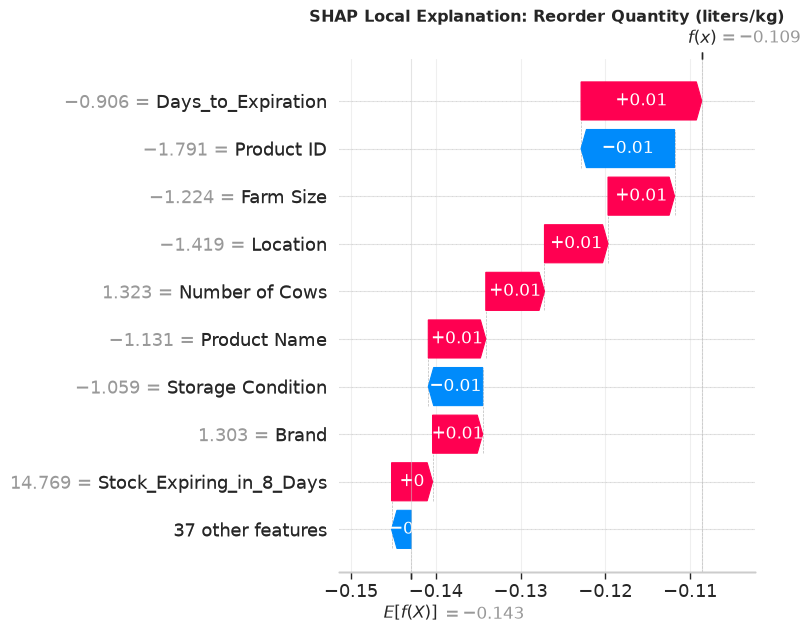

In [31]:
INSTANCE_IDX = 0
action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(
        f"\nGenerating Local Explanation for Action: {action_name} (Transaction #{INSTANCE_IDX})"
    )

    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        base_value = background_outputs[:, action_idx].mean().item()

    instance_shap_values = shap_values[action_idx][INSTANCE_IDX]
    instance_feature_values = S_matrix[INSTANCE_IDX]

    explanation = shap.Explanation(
        values=instance_shap_values,
        base_values=base_value,
        data=instance_feature_values,
        feature_names=state_cols,
    )

    plt.figure(figsize=(10, 6))
    plt.title(f"SHAP Local Explanation: {action_name}")
    shap.waterfall_plot(explanation, max_display=10, show=False)
    plt.tight_layout()
    plt.show()

#### Summary Profile



Generating Global Summary for 'Price per Unit (sold)' across test batch...


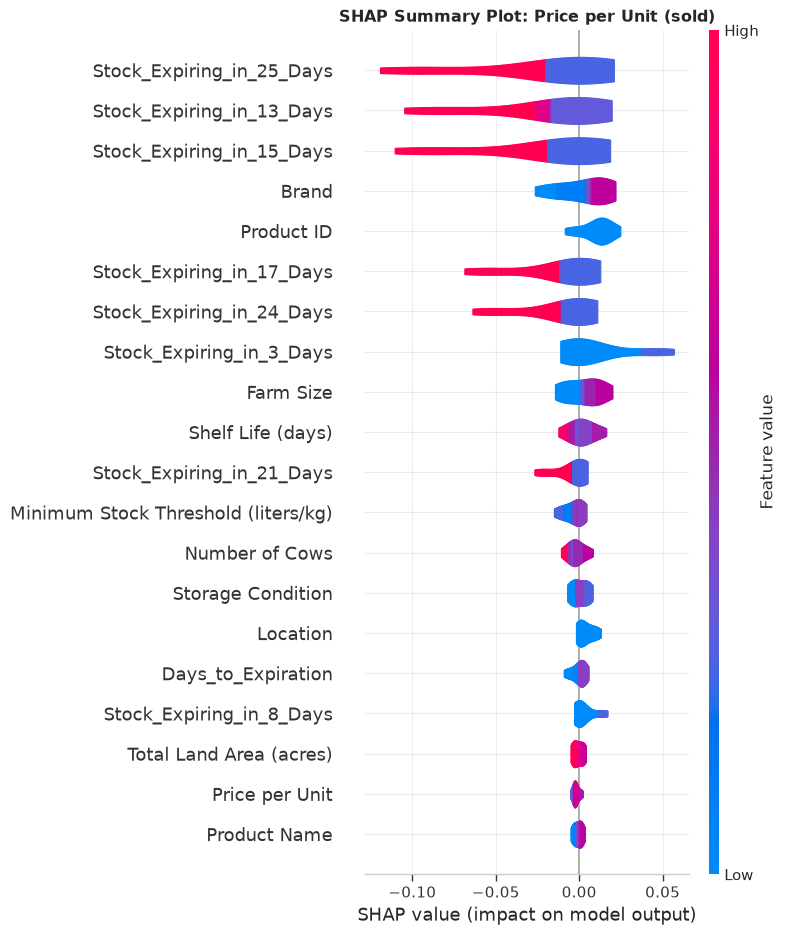

In [32]:
print("\nGenerating Global Summary for 'Price per Unit (sold)' across test batch...")
plt.figure(figsize=(10, 6))
plt.title(f"SHAP Summary Plot: {action_names[0]}")
shap.summary_plot(
    shap_values[0],
    test_tensor.cpu().numpy(),
    feature_names=state_cols,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

### Global Explanations via Symbolic Decision Trees


#### Generate RL Agent Predictions for the Entire Dataset


In [33]:
print("Generating agent predictions to train the surrogate...")
with torch.no_grad():
    S_tensor = torch.tensor(S_matrix, dtype=torch.float32).to(device)
    _, _, A_pred_scaled = dueling_model(S_tensor)
    A_pred_scaled = A_pred_scaled.cpu().numpy()

A_pred_real = scaler_A.inverse_transform(A_pred_scaled)
print("Generating agent predictions to train the surrogate successfully...")

Generating agent predictions to train the surrogate...
Generating agent predictions to train the surrogate successfully...


#### Train the Symbolic Surrogate Models


In [34]:
from sklearn.tree import DecisionTreeRegressor

print("Training Surrogate Decision Trees on unscaled features...")
X_raw = rl_df_final[state_cols]

dt_price = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_price.fit(X_raw, A_pred_real[:, 0])

dt_reorder = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_reorder.fit(X_raw, A_pred_real[:, 1])
print("Training Surrogate Decision Trees on unscaled features successfully...")

Training Surrogate Decision Trees on unscaled features...
Training Surrogate Decision Trees on unscaled features successfully...


#### Extract Human-Readable IF-THEN Rules


In [35]:
from sklearn.tree import export_text, plot_tree

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)")
print("-" * 60)
rules_price = export_text(dt_price, feature_names=list(X_raw.columns))
print(rules_price)

print("\n" + "-" * 60)
print("GLOBAL STRATEGY RULES: REORDER QUANTITY")
print("-" * 60)
rules_reorder = export_text(dt_reorder, feature_names=list(X_raw.columns))
print(rules_reorder)


------------------------------------------------------------
GLOBAL STRATEGY RULES: PRICE PER UNIT (SOLD)
------------------------------------------------------------
|--- Brand <= 4.50
|   |--- Farm Size <= 1.50
|   |   |--- Brand <= 1.50
|   |   |   |--- value: [51.59]
|   |   |--- Brand >  1.50
|   |   |   |--- value: [52.21]
|   |--- Farm Size >  1.50
|   |   |--- Brand <= 1.50
|   |   |   |--- value: [52.31]
|   |   |--- Brand >  1.50
|   |   |   |--- value: [53.02]
|--- Brand >  4.50
|   |--- Farm Size <= 1.50
|   |   |--- Farm Size <= 0.50
|   |   |   |--- value: [52.64]
|   |   |--- Farm Size >  0.50
|   |   |   |--- value: [53.22]
|   |--- Farm Size >  1.50
|   |   |--- Days_to_Expiration <= 29.50
|   |   |   |--- value: [53.41]
|   |   |--- Days_to_Expiration >  29.50
|   |   |   |--- value: [54.20]


------------------------------------------------------------
GLOBAL STRATEGY RULES: REORDER QUANTITY
------------------------------------------------------------
|--- Stock_Exp

#### Evaluate Surrogate Fidelity ($R^2$ Score)


In [36]:
score_price = dt_price.score(X_raw, A_pred_real[:, 0])
score_inv = dt_reorder.score(X_raw, A_pred_real[:, 1])

print("\nSurrogate Fidelity Check (R^2 Score):")
print(f"-> Pricing Strategy Tree Fidelity: {score_price:.4f}")
print(f"-> Reorder Strategy Tree Fidelity: {score_inv:.4f}")

if score_price < 0.70 or score_inv < 0.70:
    print(
        "\n* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3)."
    )
    print(
        "  To increase fidelity, increase max_depth, though this will reduce human interpretability."
    )


Surrogate Fidelity Check (R^2 Score):
-> Pricing Strategy Tree Fidelity: 0.2869
-> Reorder Strategy Tree Fidelity: 0.2344

* Note: A lower fidelity score is expected when severely restricting tree depth (max_depth=3).
  To increase fidelity, increase max_depth, though this will reduce human interpretability.


#### Visualizing the Strategy Tree



Generating Decision Tree Visualization for Pricing Strategy...


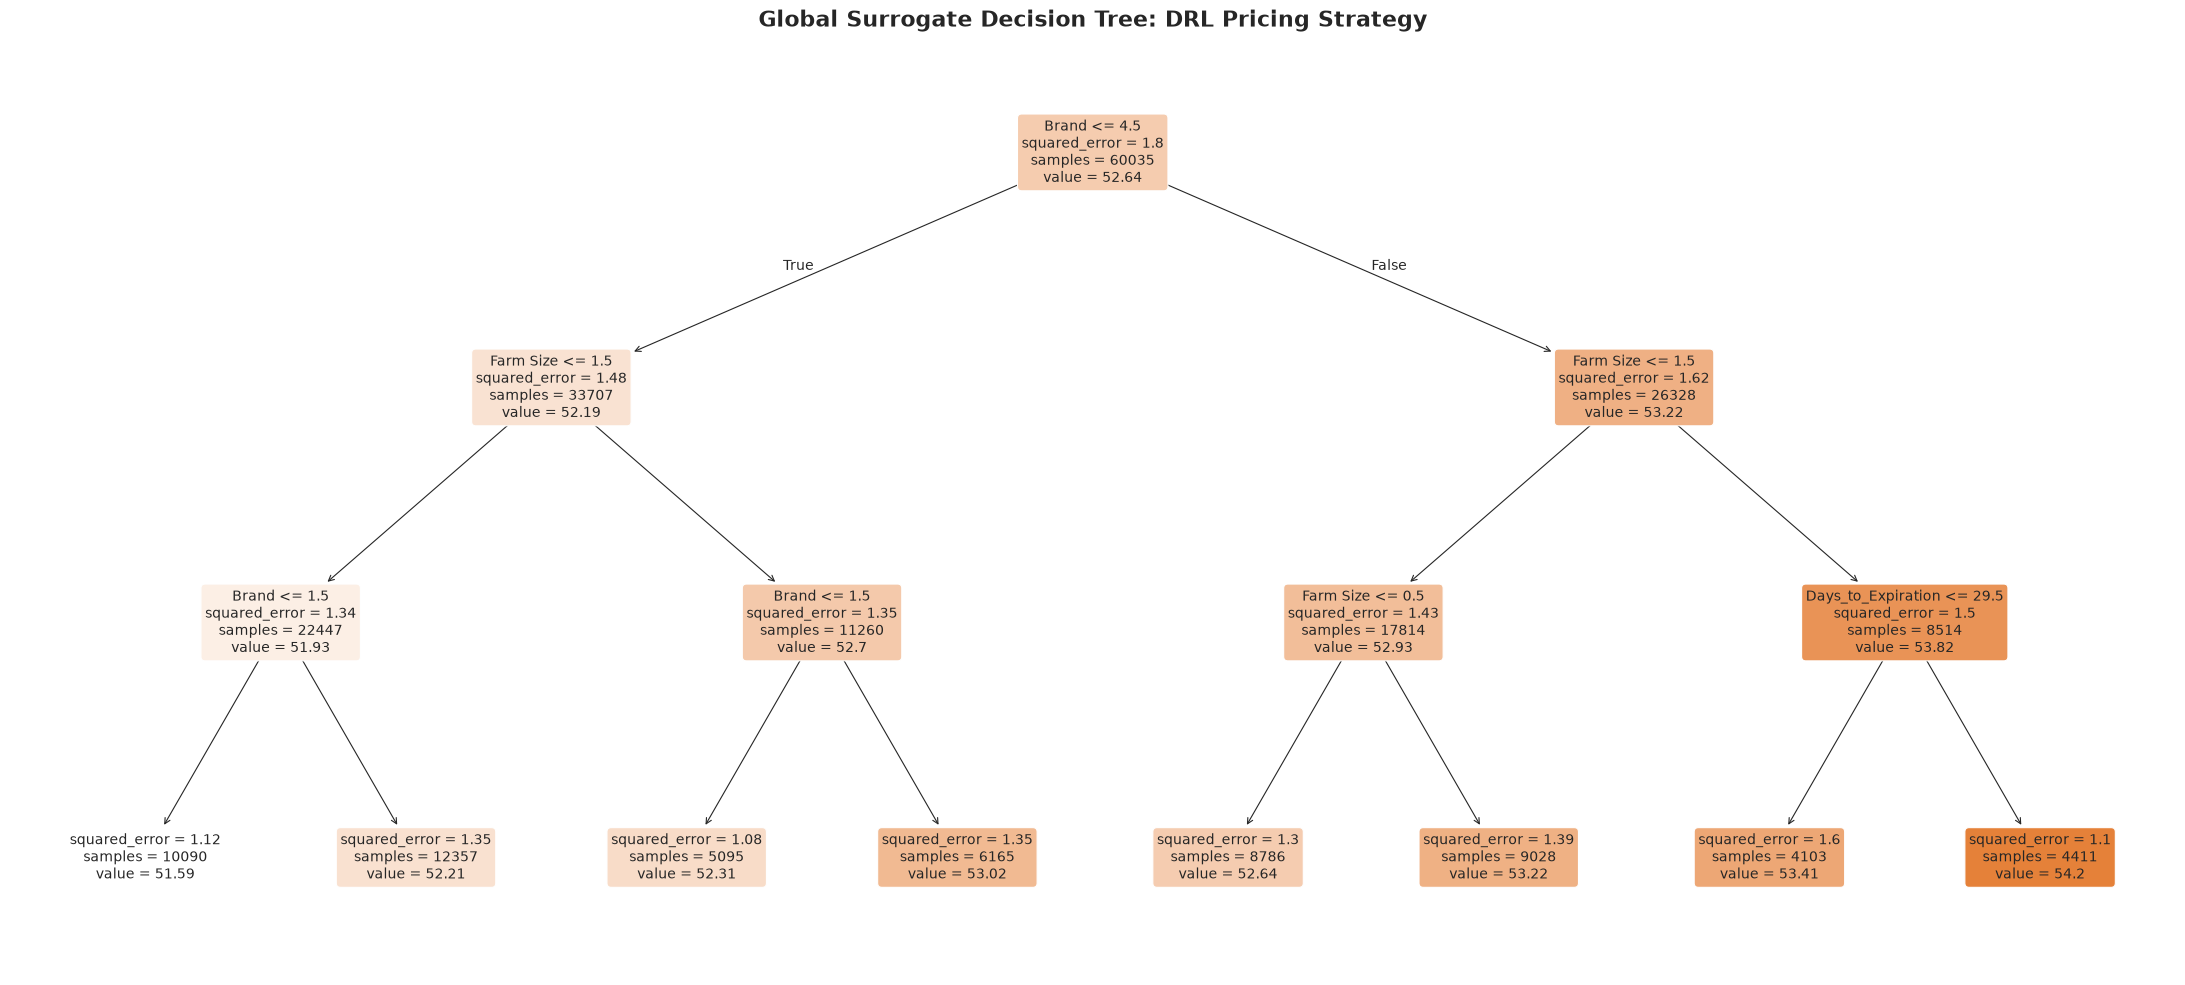

In [37]:
print("\nGenerating Decision Tree Visualization for Pricing Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_price,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Pricing Strategy", fontsize=16)
plt.tight_layout()
plt.show()


Generating Decision Tree Visualization for Reordering Strategy...


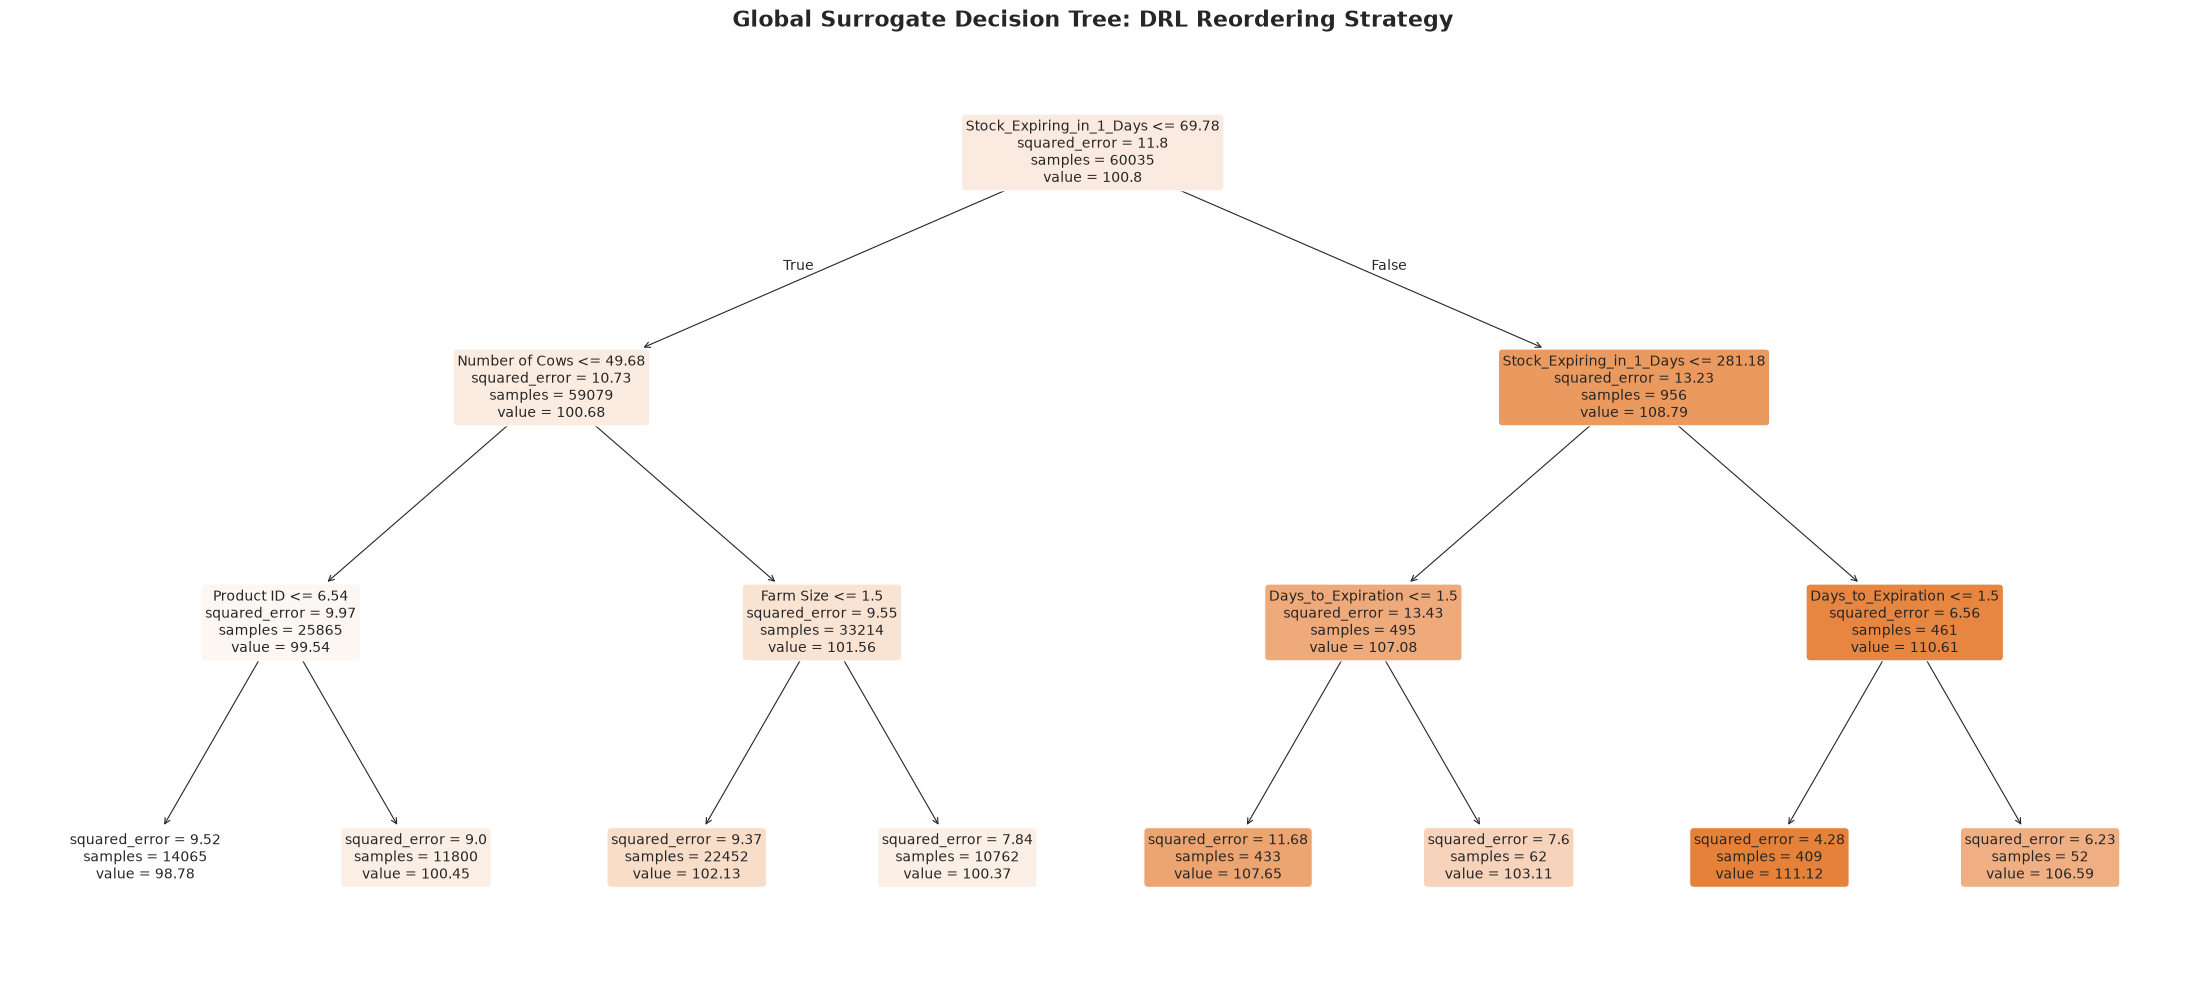

In [38]:
print("\nGenerating Decision Tree Visualization for Reordering Strategy...")
plt.figure(figsize=(22, 10))
plot_tree(
    dt_reorder,
    feature_names=list(X_raw.columns),
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
)
plt.title("Global Surrogate Decision Tree: DRL Reordering Strategy", fontsize=16)
plt.tight_layout()
plt.show()

### Reward Decomposition (Post-Hoc Financial Surrogate)


#### Prepare Data for the Reward Surrogate


In [39]:
print("Preparing State-Action paired data...")
X_hist = np.hstack([S_matrix, A_matrix])
Y_hist = rl_df_final[
    ["Gross_Profit", "Waste_Penalty", "Holding_Cost", "Stockout_Penalty"]
].values

X_agent_policy = np.hstack([S_matrix, A_pred_scaled])
feature_names_extended = state_cols + action_cols
print("Preparing State-Action paired data successfully...")

Preparing State-Action paired data...
Preparing State-Action paired data successfully...


#### Train the Multi-Output Reward Surrogate


In [40]:
from sklearn.ensemble import RandomForestRegressor

print("Training Multi-Output Random Forest Surrogate for Reward Decomposition...")
reward_surrogate = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
reward_surrogate.fit(X_hist, Y_hist)
print(
    "Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully..."
)

Training Multi-Output Random Forest Surrogate for Reward Decomposition...
Training Multi-Output Random Forest Surrogate for Reward Decomposition successfully...


#### Predict Sub-Rewards for the Agent's Policy


In [41]:
print("Decomposing Agent's Expected Rewards...")
Y_agent_expected = reward_surrogate.predict(X_agent_policy)
print("Decomposing Agent's Expected Rewards successfully...")

Decomposing Agent's Expected Rewards...
Decomposing Agent's Expected Rewards successfully...


#### Visualizing Reward Decomposition for a Specific Transaction


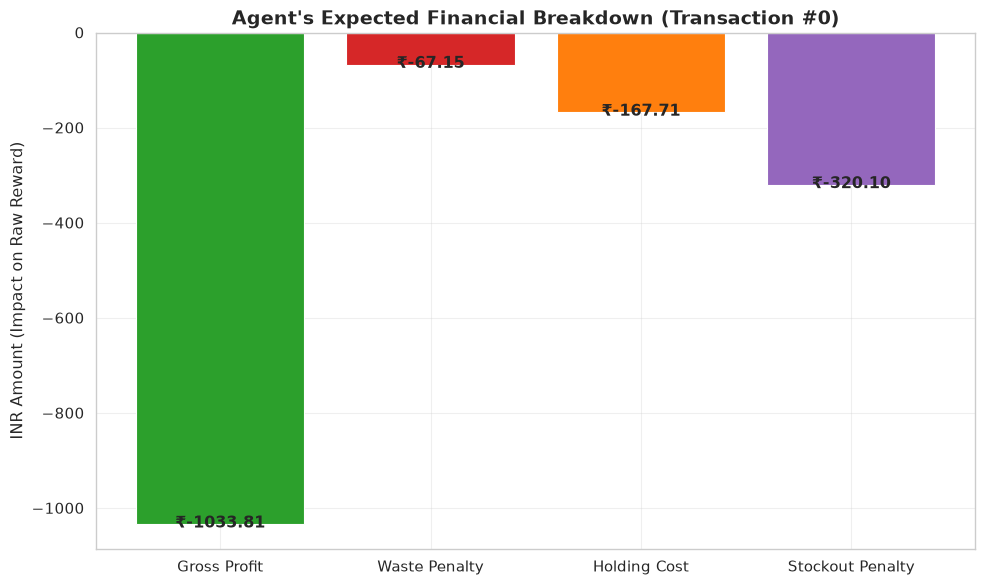

In [42]:
sub_rewards = Y_agent_expected[INSTANCE_IDX]

labels = ["Gross Profit", "Waste Penalty", "Holding Cost", "Stockout Penalty"]
values = [sub_rewards[0], -sub_rewards[1], -sub_rewards[2], -sub_rewards[3]]
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#9467bd"]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)
plt.axhline(0, color="black", linewidth=1.2)
plt.title(
    f"Agent's Expected Financial Breakdown (Transaction #{INSTANCE_IDX})", fontsize=14
)
plt.ylabel("INR Amount (Impact on Raw Reward)")

for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (5 if v > 0 else -15),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

#### SHAP Analysis: Isolating a Specific Objective (Waste Penalty)



Applying SHAP to explain how the Agent controls the 'Waste Penalty' Objective...


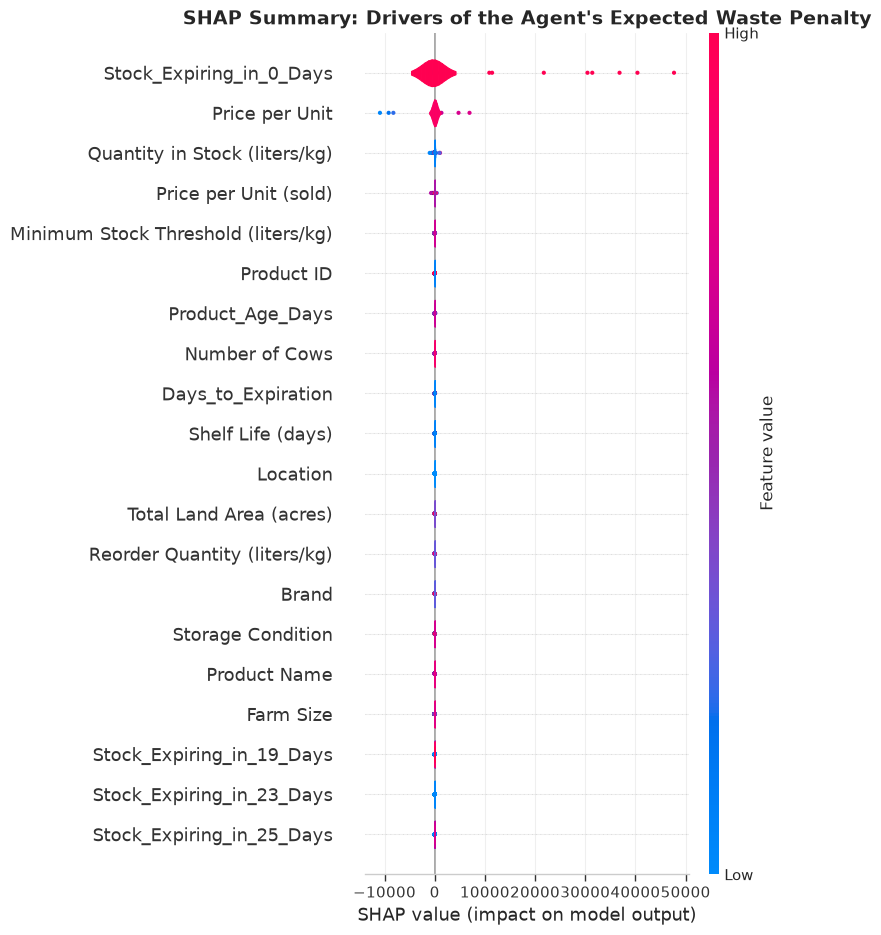

In [43]:
print(
    "\nApplying SHAP to explain how the Agent controls the 'Waste Penalty' Objective..."
)
tree_explainer = shap.TreeExplainer(reward_surrogate)

X_explain = X_agent_policy[:200]
shap_values_rf = tree_explainer.shap_values(X_explain)

if isinstance(shap_values_rf, list):
    waste_shap_values = shap_values_rf[1]
else:
    waste_shap_values = shap_values_rf[:, :, 1]

plt.figure(figsize=(12, 6))
plt.title("SHAP Summary: Drivers of the Agent's Expected Waste Penalty", fontsize=14)
shap.summary_plot(
    waste_shap_values,
    X_explain,
    feature_names=feature_names_extended,
    show=False,
    plot_type="violin",
)
plt.tight_layout()
plt.show()

### Post-Hoc XAI Evaluation & Validation


#### Global Fidelity vs. Interpretability Trade-Off


Evaluating Global Surrogate Fidelity across explanation complexities...


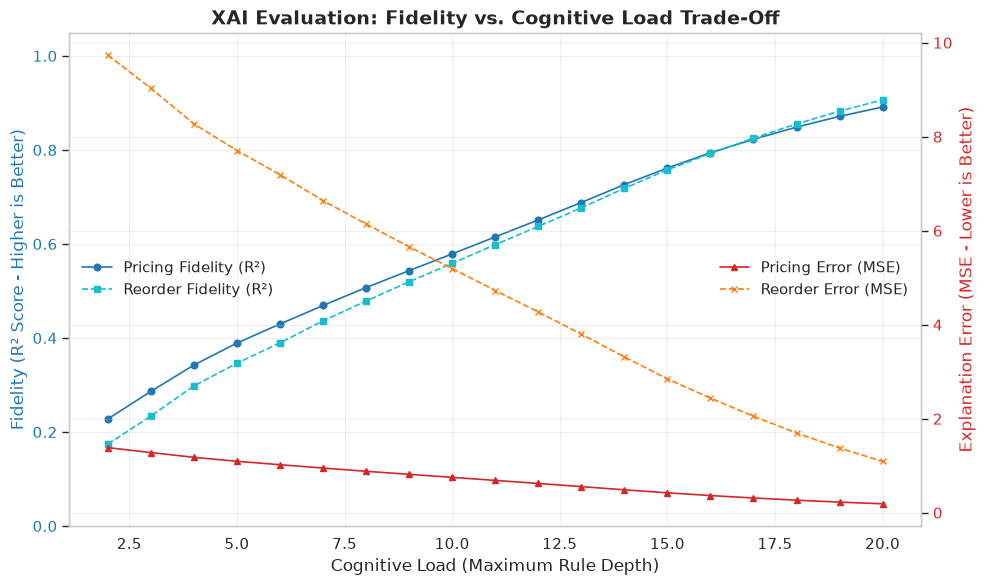

In [44]:
from sklearn.metrics import mean_squared_error, r2_score

print("Evaluating Global Surrogate Fidelity across explanation complexities...")

depths = range(2, 21)
fidelity_r2_price = []
fidelity_r2_reorder = []
mse_price = []
mse_reorder = []

X_raw = rl_df_final[state_cols]
y_price = A_pred_real[:, 0]
y_reorder = A_pred_real[:, 1]

for d in depths:
    dt_p = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_p.fit(X_raw, y_price)
    preds_p = dt_p.predict(X_raw)
    fidelity_r2_price.append(r2_score(y_price, preds_p))
    mse_price.append(mean_squared_error(y_price, preds_p))

    dt_r = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_r.fit(X_raw, y_reorder)
    preds_r = dt_r.predict(X_raw)
    fidelity_r2_reorder.append(r2_score(y_reorder, preds_r))
    mse_reorder.append(mean_squared_error(y_reorder, preds_r))

# Plotting the Trade-off Curve
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = "tab:blue"
color2 = "tab:cyan"
ax1.set_xlabel("Cognitive Load (Maximum Rule Depth)", fontsize=12)
ax1.set_ylabel("Fidelity (R² Score - Higher is Better)", color=color1, fontsize=12)
ax1.plot(
    depths, fidelity_r2_price, marker="o", label="Pricing Fidelity (R²)", color=color1
)
ax1.plot(
    depths,
    fidelity_r2_reorder,
    marker="s",
    linestyle="--",
    label="Reorder Fidelity (R²)",
    color=color2,
)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_ylim((0, 1.05))
ax1.legend(loc="center left")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color3 = "tab:red"
color4 = "tab:orange"
ax2.set_ylabel("Explanation Error (MSE - Lower is Better)", color=color3, fontsize=12)
ax2.plot(depths, mse_price, marker="^", label="Pricing Error (MSE)", color=color3)
ax2.plot(
    depths,
    mse_reorder,
    marker="x",
    linestyle="--",
    label="Reorder Error (MSE)",
    color=color4,
)
ax2.tick_params(axis="y", labelcolor=color3)
ax2.legend(loc="center right")

plt.title("XAI Evaluation: Fidelity vs. Cognitive Load Trade-Off", fontsize=14)
fig.tight_layout()
plt.savefig(
    "./plots/TD3_Fidelity_vs_Cognitive_Load.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

#### Local Fidelity (SHAP Completeness Axiom)


In [45]:
print("\nEvaluating Local Explanation Fidelity (SHAP Completeness Axiom)...")

local_fidelity_passed = True
action_names = ["Price per Unit (sold)", "Reorder Quantity (liters/kg)"]

for action_idx, action_name in enumerate(action_names):
    print(f"\nVerifying Completeness for Action: {action_name}")

    with torch.no_grad():
        background_outputs = action_model(background_tensor)
        expected_val = background_outputs[:, action_idx].mean().item()
        actual_preds = action_model(test_tensor)[:, action_idx].cpu().numpy()

    shap_sums = shap_values[action_idx].sum(axis=1)

    for i in range(len(test_indices)):
        explanation_pred = shap_sums[i] + expected_val
        actual_pred = actual_preds[i]
        diff = abs(explanation_pred - actual_pred)

        print(
            f" Instance #{i} | Actual DRL Output: {actual_pred:.4f} | SHAP Explained Output: {explanation_pred:.4f} | Math Diff: {diff:.6f}"
        )

        if diff > 1e-4:
            local_fidelity_passed = False

if local_fidelity_passed:
    print(
        "\n[SUCCESS] Local Fidelity Check Passed: SHAP values strictly reconstruct the DRL agent's local decisions."
    )
else:
    print(
        "\n[WARNING] Local Fidelity Check Failed: SHAP explanations do not sum to the DRL output. The approximation is leaking information."
    )


Evaluating Local Explanation Fidelity (SHAP Completeness Axiom)...

Verifying Completeness for Action: Price per Unit (sold)
 Instance #0 | Actual DRL Output: -0.0921 | SHAP Explained Output: -0.1042 | Math Diff: 0.012074
 Instance #1 | Actual DRL Output: -0.1339 | SHAP Explained Output: -0.1438 | Math Diff: 0.009982
 Instance #2 | Actual DRL Output: -0.1249 | SHAP Explained Output: -0.1220 | Math Diff: 0.002888
 Instance #3 | Actual DRL Output: -0.1981 | SHAP Explained Output: -0.1912 | Math Diff: 0.006972
 Instance #4 | Actual DRL Output: -0.1861 | SHAP Explained Output: -0.1713 | Math Diff: 0.014791

Verifying Completeness for Action: Reorder Quantity (liters/kg)
 Instance #0 | Actual DRL Output: -0.1110 | SHAP Explained Output: -0.1086 | Math Diff: 0.002365
 Instance #1 | Actual DRL Output: -0.1228 | SHAP Explained Output: -0.1297 | Math Diff: 0.006868
 Instance #2 | Actual DRL Output: -0.2357 | SHAP Explained Output: -0.2411 | Math Diff: 0.005427
 Instance #3 | Actual DRL Output:

### Selectivity & Perturbation (PI / Masking)


#### Identify Top and Bottom Features from SHAP


In [46]:
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)
sorted_feature_indices = np.argsort(mean_abs_shap)[::-1]

top_3_indices = sorted_feature_indices[:3]
top_3_features = [state_cols[i] for i in top_3_indices]
print(f"Top 3 Features identified by SHAP: \n{top_3_features}\n")

bottom_3_indices = sorted_feature_indices[-3:]
bottom_3_features = [state_cols[i] for i in bottom_3_indices]

Top 3 Features identified by SHAP: 
['Stock_Expiring_in_25_Days', 'Stock_Expiring_in_13_Days', 'Stock_Expiring_in_15_Days']



#### Collinearity Check


In [47]:
print("Executing Collinearity Check...")

for feat in top_3_features:
    corrs = []
    for f1, f2, val in collinear_pairs:
        if feat == f1:
            corrs.append(f2)
        elif feat == f2:
            corrs.append(f1)

    if corrs:
        print(
            f" [!] WARNING: '{feat}' is highly correlated with {corrs}. Masking it might trigger the agent to use the correlated proxy."
        )
    else:
        print(f" [OK] '{feat}' is independent. No collinearity detected.")

Executing Collinearity Check...
 [OK] 'Stock_Expiring_in_25_Days' is independent. No collinearity detected.
 [OK] 'Stock_Expiring_in_13_Days' is independent. No collinearity detected.
 [OK] 'Stock_Expiring_in_15_Days' is independent. No collinearity detected.


#### Permutation Importance / Masking Evaluation


In [48]:
print("\nEvaluating Agent Performance Drop (Perturbation Importance)...")


def evaluate_policy_reward(state_tensor):
    with torch.no_grad():
        _, _, pred_actions = dueling_model(state_tensor)

    X_eval = np.hstack([state_tensor.cpu().numpy(), pred_actions.cpu().numpy()])
    sub_rewards = reward_surrogate.predict(X_eval)

    raw_rewards = (
        sub_rewards[:, 0] - sub_rewards[:, 1] - sub_rewards[:, 2] - sub_rewards[:, 3]
    )
    return raw_rewards.mean()


# A. Calculate Baseline Expected Reward
baseline_reward = evaluate_policy_reward(test_tensor)
print(f"-> Baseline Expected Reward (Unperturbed): ₹{baseline_reward:.2f}")

# B. Perturb Top 3 Features (Masking)
perturbed_states_top = test_tensor.clone()
for idx in top_3_indices:
    perturbed_states_top[:, idx] = 0.0

degraded_reward_top = evaluate_policy_reward(perturbed_states_top)
drop_pct_top = ((baseline_reward - degraded_reward_top) / abs(baseline_reward)) * 100
print(f"-> Expected Reward (Top 3 Features Masked): ₹{degraded_reward_top:.2f}")
print(f"-> Performance Impact: {drop_pct_top:.2f}% drop")

# C. Perturb Bottom 3 Features (Sanity Check)
print(f"\nSanity Check: Masking Bottom 3 Features \n{bottom_3_features}...")
perturbed_states_bottom = test_tensor.clone()
for idx in bottom_3_indices:
    perturbed_states_bottom[:, idx] = 0.0

degraded_reward_bottom = evaluate_policy_reward(perturbed_states_bottom)
drop_pct_bottom = (
    (baseline_reward - degraded_reward_bottom) / abs(baseline_reward)
) * 100
print(f"-> Expected Reward (Bottom 3 Features Masked): ₹{degraded_reward_bottom:.2f}")
print(f"-> Performance Impact: {drop_pct_bottom:.2f}% drop")


Evaluating Agent Performance Drop (Perturbation Importance)...
-> Baseline Expected Reward (Unperturbed): ₹-2640.51
-> Expected Reward (Top 3 Features Masked): ₹-2613.90
-> Performance Impact: -1.01% drop

Sanity Check: Masking Bottom 3 Features 
['Stock_Expiring_in_7_Days', 'Stock_Expiring_in_14_Days', 'Stock_Expiring_in_23_Days']...
-> Expected Reward (Bottom 3 Features Masked): ₹-2640.51
-> Performance Impact: 0.00% drop


#### Visualization of Performance Degradation


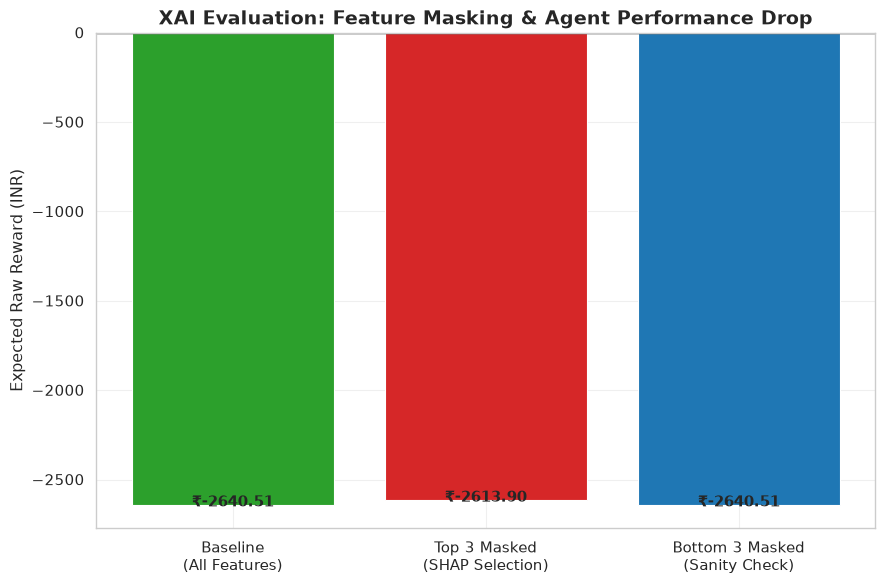

In [49]:
labels = [
    "Baseline\n(All Features)",
    "Top 3 Masked\n(SHAP Selection)",
    "Bottom 3 Masked\n(Sanity Check)",
]
values = [baseline_reward, degraded_reward_top, degraded_reward_bottom]
colors = ["#2ca02c", "#d62728", "#1f77b4"]

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, values, color=colors)
plt.title("XAI Evaluation: Feature Masking & Agent Performance Drop", fontsize=14)
plt.ylabel("Expected Raw Reward (INR)")
plt.axhline(0, color="black", linewidth=1)

for bar, v in zip(bars, values):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + (10 if v > 0 else -30),
        f"₹{v:.2f}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

### Stability & Robustness Profiling (Lipschitz Continuity)


#### Generate Local Perturbations (Noise Injection)


In [50]:
print("Generating 100 near-identical state transitions...")
NUM_SAMPLES = 100
ACTION_IDX = 0

base_state = S_matrix[INSTANCE_IDX]

np.random.seed(42)
noise = np.random.normal(loc=0.0, scale=0.01, size=(NUM_SAMPLES, STATE_DIM))
perturbed_states = base_state + noise

perturbed_states[0] = base_state
perturbed_tensor = torch.tensor(perturbed_states, dtype=torch.float32).to(device)

Generating 100 near-identical state transitions...


#### Extract SHAP Explanations for Perturbed States


In [51]:
print("Calculating SHAP values for perturbed states...")
shap_values_perturbed = explainer.shap_values(perturbed_tensor)

if isinstance(shap_values_perturbed, list):
    shap_action_perturbed = shap_values_perturbed[ACTION_IDX]
else:
    shap_action_perturbed = shap_values_perturbed[:, :, ACTION_IDX]

base_shap = shap_action_perturbed[0]

Calculating SHAP values for perturbed states...


#### Calculate Lipschitz Continuity and Variance


In [52]:
from scipy.spatial.distance import cdist

print("Calculating Lipschitz constants and feature-wise variance...")

dx = cdist([base_state], perturbed_states, metric="euclidean")[0] + 1e-9
de = cdist([base_shap], shap_action_perturbed, metric="euclidean")[0]

lipschitz_ratios = de / dx
local_lipschitz_constant = np.max(lipschitz_ratios[1:])

shap_variances = np.var(shap_action_perturbed, axis=0)

print("\nStability Metrics:")
print("-" * 60)
print(f"-> Local Lipschitz Constant (L): {local_lipschitz_constant:.4f}")
if local_lipschitz_constant < 5.0:
    print(
        "   [OK] Low Lipschitz constant. The explanations are highly stable and trustworthy."
    )
else:
    print(
        "   [WARNING] High Lipschitz constant. The explanations are fragile to noise."
    )

Calculating Lipschitz constants and feature-wise variance...

Stability Metrics:
------------------------------------------------------------
-> Local Lipschitz Constant (L): 0.4674
   [OK] Low Lipschitz constant. The explanations are highly stable and trustworthy.


#### Visualization of XAI Robustness



Generating Robustness Profile Visualizations...


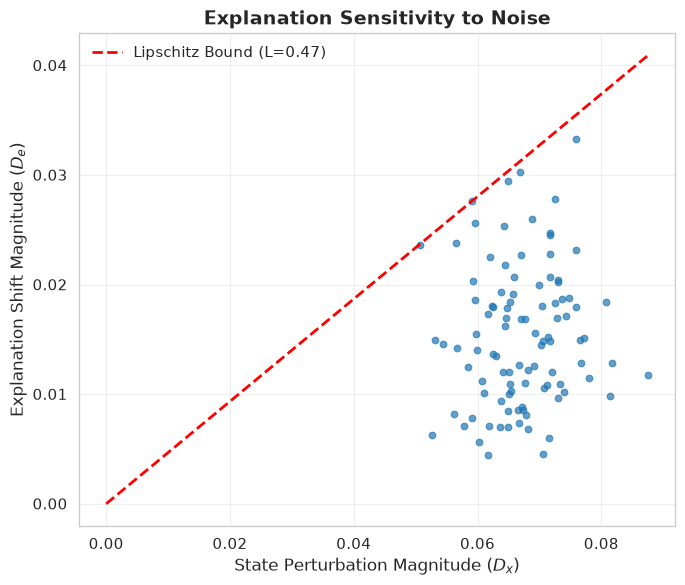

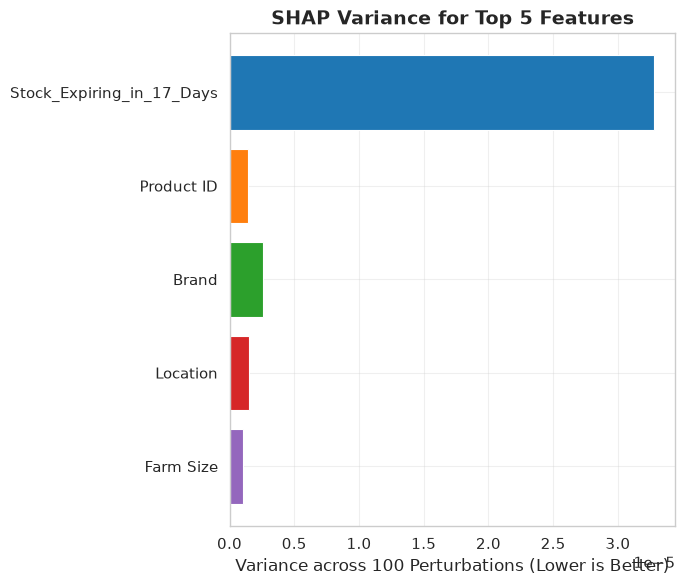

In [53]:
print("\nGenerating Robustness Profile Visualizations...")

# Plot 1: Explanation Sensitivity to Noise
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

ax.scatter(dx[1:], de[1:], alpha=0.7, color="#1f77b4")
ax.set_title("Explanation Sensitivity to Noise", fontsize=14)
ax.set_xlabel(r"State Perturbation Magnitude ($D_x$)", fontsize=12)
ax.set_ylabel(r"Explanation Shift Magnitude ($D_e$)", fontsize=12)
ax.grid(alpha=0.3)

x_vals = np.linspace(0, np.max(dx), 100)
y_vals = local_lipschitz_constant * x_vals

ax.plot(
    x_vals,
    y_vals,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Lipschitz Bound (L={local_lipschitz_constant:.2f})",
)
ax.legend()
plt.tight_layout()
plt.savefig(
    "./plots/TD3_Explanation_Sensitivity_to_Noise.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

# Plot 2: SHAP Variance of Top Features
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)

top_5_indices = np.argsort(np.abs(base_shap))[::-1][:5]
top_5_features = [state_cols[i] for i in top_5_indices]
top_5_variances = shap_variances[top_5_indices]

ax.barh(
    top_5_features[::-1],
    top_5_variances[::-1],
    color=["#9467bd", "#d62728", "#2ca02c", "#ff7f0e", "#1f77b4"],
)

ax.set_title("SHAP Variance for Top 5 Features", fontsize=14)
ax.set_xlabel("Variance across 100 Perturbations (Lower is Better)", fontsize=12)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "./plots/TD3_SHAP_Variance_Top5_Features.pdf",
    format="pdf",
    dpi=1200,
    bbox_inches="tight",
)
plt.show()

## Architectural Metric Summary


In [54]:
import pandas as pd

TD3_data = {
    "Average Reward": f"{A_pred_scaled.mean():.4f}",
    "Policy Loss": f"{training_history['actor_loss'][-1]:.4f}",
    "Value Loss": f"{training_history['critic_loss'][-1]:.4f}",
    "MAE": f"{p_mae:.4f}",
    "RMSE": f"{p_rmse:.4f}",
    "R²": f"{p_r2:.4f}",
    "Pricing Accuracy": f"{p_acc:.2f}%",
    "Reordering Accuracy": f"{r_acc:.2f}%",
    "Overall DRL Accuracy": f"{overall_drl_acc:.2f}%",
    "Training Time": f"{elapsed_time:.2f} sec",
    "Pricing Strategy Tree Fidelity (Depth=3)": f"{score_price * 100:.2f}%",
    "Reorder Strategy Tree Fidelity (Depth=3)": f"{score_inv * 100:.2f}%",
    "Baseline Expected Reward (Unperturbed)": f"₹{baseline_reward:.2f}",
    "Expected Reward (Top 3 Features Masked)": f"₹{degraded_reward_top:.2f}",
    "Expected Reward (Bottom 3 Features Masked):": f"₹{degraded_reward_bottom:.2f}",
    "Performance Impact (Top 3 Features Masked)": f"{drop_pct_top:.2f}%",
    "Performance Impact (Bottom 3 Features Masked)": f"{drop_pct_bottom:.2f}%",
    "Lipschitz Constant": local_lipschitz_constant,
}

TD3_df = pd.DataFrame([TD3_data], index=["TD3"]).T
TD3_df.to_csv("./results/TD3_df.csv", index=True)
TD3_df

,TD3
Average Reward,-0.1098
Policy Loss,-0.0008
Value Loss,0.5339
MAE,23.0733
RMSE,26.9388
R²,-0.0300
Pricing Accuracy,72.87%
Reordering Accuracy,70.91%
Overall DRL Accuracy,71.89%
Training Time,12.91 sec
